In [94]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from imblearn.over_sampling import SMOTE

import joblib

In [77]:
# Load scaled feature sets

X_train_z = joblib.load("X_train_z.pkl")
X_val_z = joblib.load("X_val_z.pkl")
X_test_z = joblib.load("X_test_z.pkl")

# Load encoded labels

y_train_encoded = joblib.load("y_train_encoded.pkl")
y_val_encoded = joblib.load("y_val_encoded.pkl")
y_test_encoded = joblib.load("y_test_encoded.pkl")

# Load SMOTE training data

X_train_smote = joblib.load("X_train_smote.pkl")
y_train_smote = joblib.load("y_train_smote.pkl")

# Load label encoder

label_encoder = joblib.load("label_encoder.pkl")

# Display dataset shapes

print("Datasets loaded successfully.")

print(f"Training set:   {X_train_z.shape}")
print(f"Validation set: {X_val_z.shape}")
print(f"Test set:       {X_test_z.shape}")

print(f"SMOTE training: {X_train_smote.shape}")

Datasets loaded successfully.
Training set:   (1873638, 17)
Validation set: (249818, 17)
Test set:       (374729, 17)
SMOTE training: (1894672, 17)


In [26]:
# Compute class weights
classes = np.unique(y_train_encoded)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.150678716001472), np.int64(1): np.float64(160.30441478439425), np.int64(2): np.float64(34.12571033075914), np.int64(3): np.float64(2.4393787105509843), np.int64(4): np.float64(1.6117704340405619), np.int64(5): np.float64(3.4431241822378382), np.int64(6): np.float64(6691.564285714286), np.int64(7): np.float64(145.7403546981954)}


## Random Forest — Baseline

In [27]:
# RandomForest Model
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1                
)
rf_model.fit(X_train_z, y_train_encoded)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")


Training Time: 188.37 seconds


[INFO] Generating predictions and evaluating model performance...

IDS Evaluation Dashboard - Test Set
[+] Accuracy Score : 0.9579
[+] Macro F1-Score : 0.6687
------------------------------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.95      0.97    310868
         Bot       0.03      0.95      0.07       292
 Brute Force       0.69      0.97      0.80      1372
        DDoS       1.00      1.00      1.00     19202
         DoS       0.97      0.98      0.97     29062
    PortScan       0.99      1.00      0.99     13604
 Rare Attack       1.00      0.29      0.44         7
  Web Attack       0.05      0.93      0.10       322

    accuracy                           0.96    374729
   macro avg       0.71      0.88      0.67    374729
weighted avg       0.99      0.96      0.97    374729



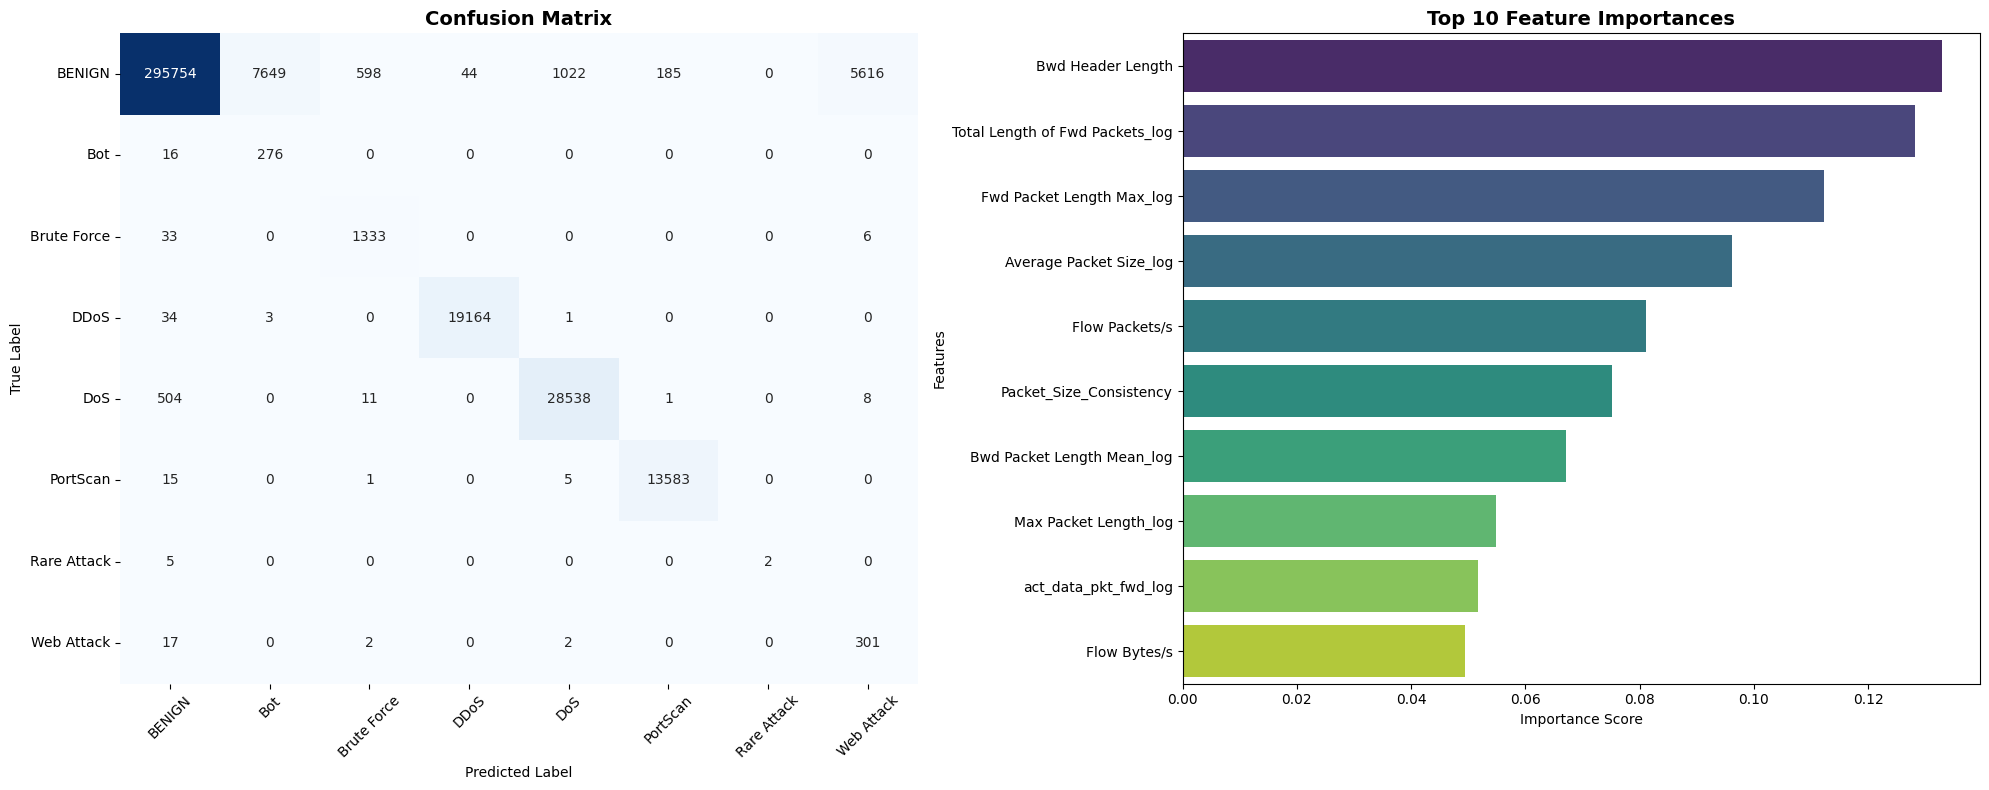

In [28]:
# Metadata Configuration

target_names = label_encoder.classes_.tolist()
feature_cols = X_test_z.columns.tolist()


# Model Predictions and Evaluation

print("[INFO] Generating predictions and evaluating model performance...")

y_pred = rf_model.predict(X_test_z)

print("\n" + "=" * 60)
print("IDS Evaluation Dashboard - Test Set")
print("=" * 60)

print(
    f"[+] Accuracy Score : "
    f"{accuracy_score(y_test_encoded, y_pred):.4f}"
)

print(
    f"[+] Macro F1-Score : "
    f"{f1_score(y_test_encoded, y_pred, average='macro'):.4f}"
)

print("-" * 60)
print("\nDetailed Classification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=target_names,
        zero_division=0
    )
)

print("=" * 60)


# Visualization Dashboard

fig, axes = plt.subplots(1, 2, figsize=(20, 8))


# Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=target_names,
    yticklabels=target_names
)

axes[0].set_title(
    'Confusion Matrix',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=45)


# Feature Importance

importances = rf_model.feature_importances_

top_n = min(10, len(feature_cols))

indices = np.argsort(importances)[::-1][:top_n]

feature_labels = [
    feature_cols[i]
    for i in indices
]

sns.barplot(
    x=importances[indices],
    y=feature_labels,
    ax=axes[1],
    hue=feature_labels,
    palette='viridis',
    legend=False
)

axes[1].set_title(
    'Top 10 Feature Importances',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

## Random Forest Custom Class Weights

In [103]:
class_weight={
    0: 1,
    1: 25,
    2: 10,
    3: 1,
    4: 2,
    5: 1,
    6: 80,
    7: 20
}

In [104]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=class_weight,
    random_state=42,
    n_jobs=-1
)

start = time.time()

rf_model.fit(
    X_train_z,
    y_train_encoded
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

Training Time: 572.94 seconds


[INFO] Generating predictions and evaluating model performance...

IDS Evaluation Dashboard - Test Set
[+] Accuracy Score : 0.9916
[+] Macro F1-Score : 0.8245
------------------------------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99    310868
         Bot       0.64      0.64      0.64       292
 Brute Force       1.00      0.97      0.98      1372
        DDoS       1.00      1.00      1.00     19202
         DoS       0.98      0.98      0.98     29062
    PortScan       0.99      1.00      0.99     13604
 Rare Attack       1.00      0.57      0.73         7
  Web Attack       0.16      0.91      0.28       322

    accuracy                           0.99    374729
   macro avg       0.85      0.88      0.82    374729
weighted avg       0.99      0.99      0.99    374729



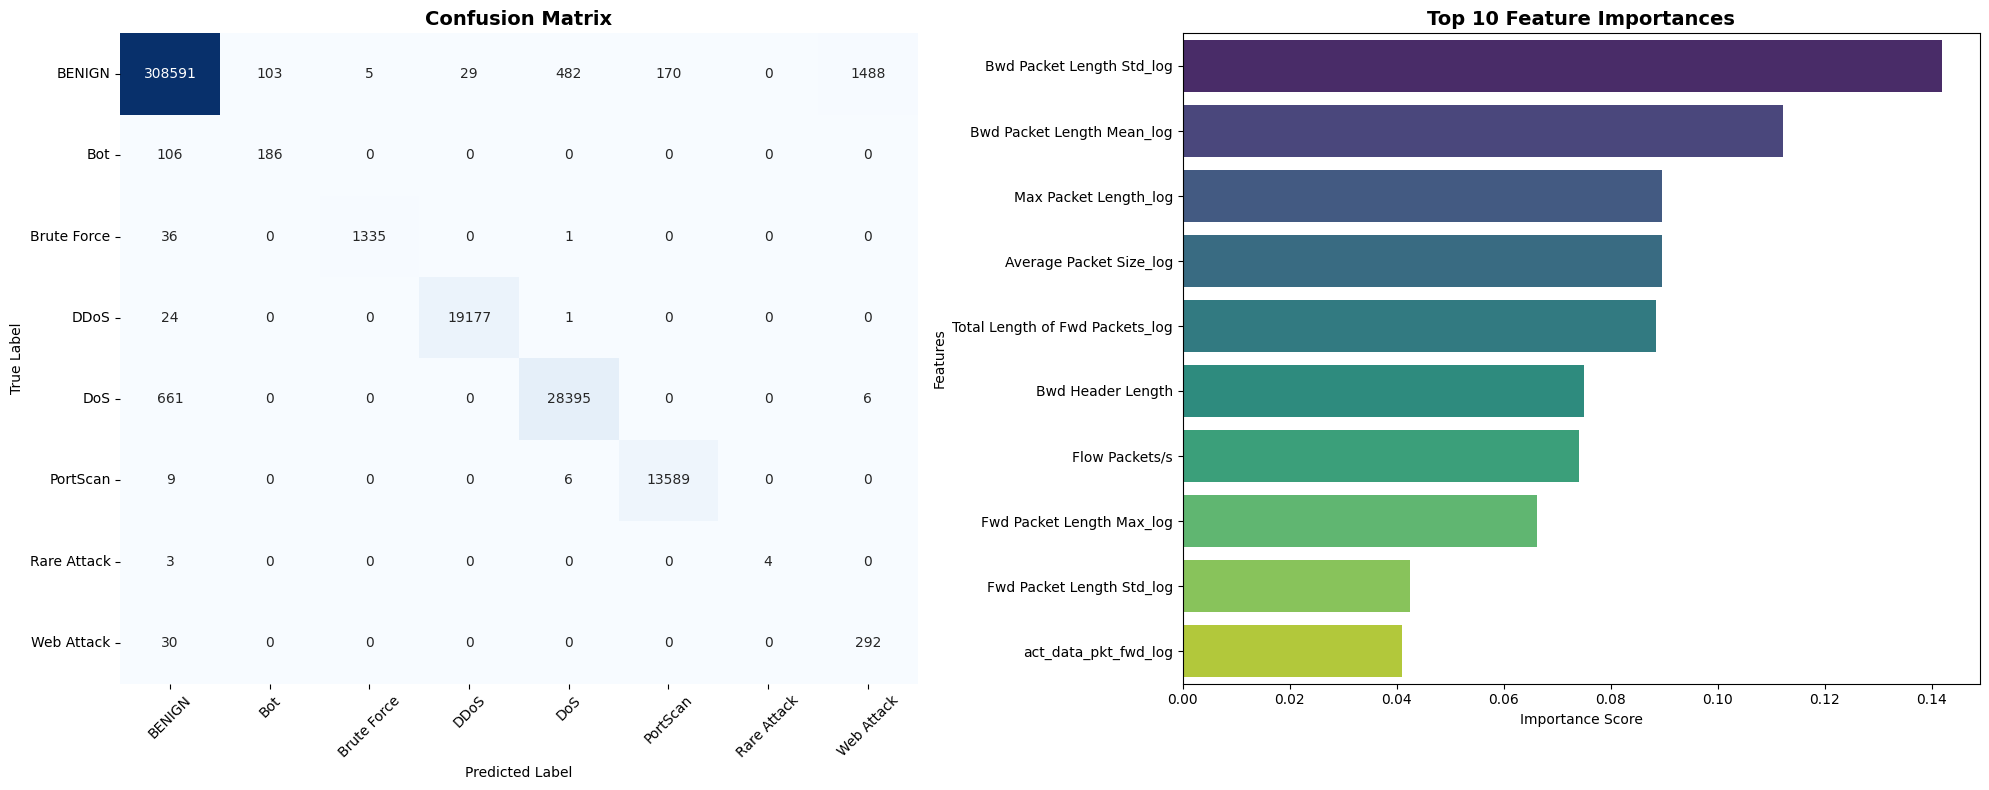

In [105]:
# Metadata Configuration

target_names = label_encoder.classes_.tolist()
feature_cols = X_test_z.columns.tolist()


# Model Predictions and Evaluation

print("[INFO] Generating predictions and evaluating model performance...")

y_pred = rf_model.predict(X_test_z)

print("\n" + "=" * 60)
print("IDS Evaluation Dashboard - Test Set")
print("=" * 60)

print(
    f"[+] Accuracy Score : "
    f"{accuracy_score(y_test_encoded, y_pred):.4f}"
)

print(
    f"[+] Macro F1-Score : "
    f"{f1_score(y_test_encoded, y_pred, average='macro'):.4f}"
)

print("-" * 60)
print("\nDetailed Classification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=target_names,
        zero_division=0
    )
)

print("=" * 60)


# Visualization Dashboard

fig, axes = plt.subplots(1, 2, figsize=(20, 8))


# Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=target_names,
    yticklabels=target_names
)

axes[0].set_title(
    'Confusion Matrix',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=45)


# Feature Importance

importances = rf_model.feature_importances_

top_n = min(10, len(feature_cols))

indices = np.argsort(importances)[::-1][:top_n]

feature_labels = [
    feature_cols[i]
    for i in indices
]

sns.barplot(
    x=importances[indices],
    y=feature_labels,
    ax=axes[1],
    hue=feature_labels,
    palette='viridis',
    legend=False
)

axes[1].set_title(
    'Top 10 Feature Importances',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

## Save Best Model 

In [109]:
joblib.dump(rf_model, "artifacts/rf_model.pkl")

['artifacts/rf_model.pkl']

In [110]:
joblib.dump(rf_model, "artifacts/rf_model.pkl")
joblib.dump(label_encoder, "artifacts/label_encoder.pkl")
joblib.dump(X_train_z.columns.tolist(), "artifacts/feature_names.pkl")

['artifacts/feature_names.pkl']

## Random Forest Custom Class Weights V2

In [100]:
class_weight_v2 = {
    0: 1,
    1: 40,
    2: 10,
    3: 1,
    4: 2,
    5: 1,
    6: 80,
    7: 5
}

In [101]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight=class_weight,
    random_state=42,
    n_jobs=-1
)

start = time.time()

rf_model.fit(
    X_train_z,
    y_train_encoded
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

Training Time: 527.39 seconds


[INFO] Generating predictions and evaluating model performance...
IDS Evaluation Dashboard - Test Set
[+] Accuracy Score : 0.9916
[+] Macro F1-Score : 0.8245

Detailed Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99    310868
         Bot       0.64      0.64      0.64       292
 Brute Force       1.00      0.97      0.98      1372
        DDoS       1.00      1.00      1.00     19202
         DoS       0.98      0.98      0.98     29062
    PortScan       0.99      1.00      0.99     13604
 Rare Attack       1.00      0.57      0.73         7
  Web Attack       0.16      0.91      0.28       322

    accuracy                           0.99    374729
   macro avg       0.85      0.88      0.82    374729
weighted avg       0.99      0.99      0.99    374729



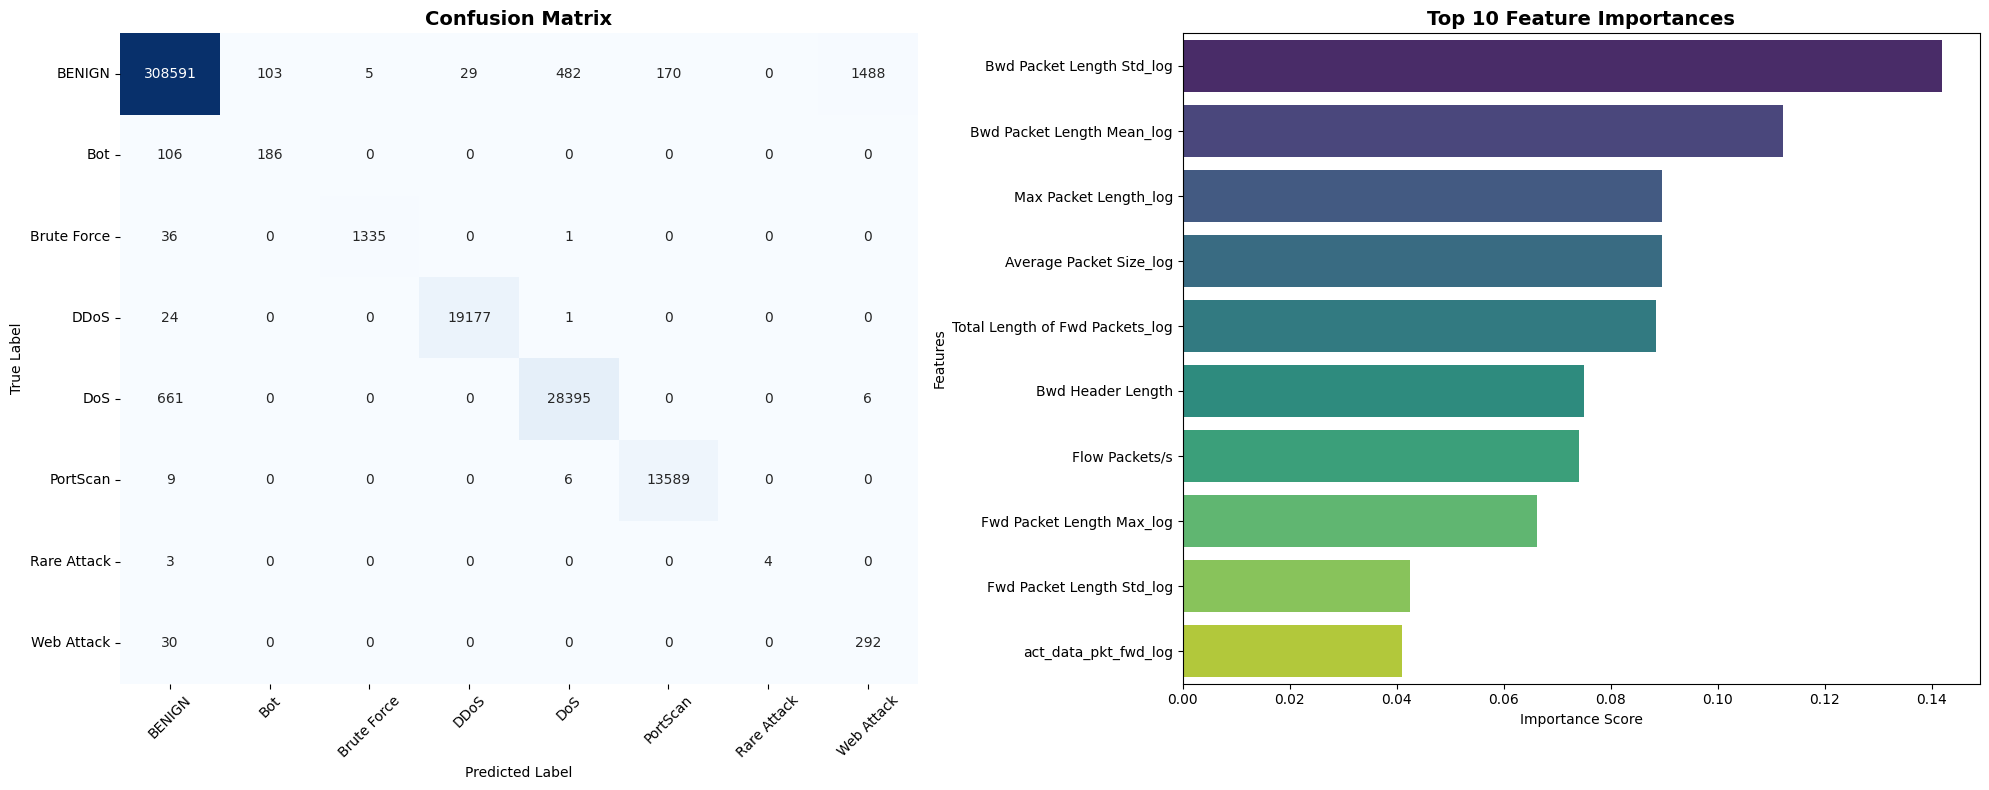

In [102]:
# Metadata Configuration

target_names = label_encoder.classes_.tolist()
feature_cols = X_test_z.columns.tolist()


# Model Predictions and Evaluation

print("[INFO] Generating predictions and evaluating model performance...")

y_pred = rf_model.predict(X_test_z)

print("IDS Evaluation Dashboard - Test Set")

print(
    f"[+] Accuracy Score : "
    f"{accuracy_score(y_test_encoded, y_pred):.4f}"
)

print(
    f"[+] Macro F1-Score : "
    f"{f1_score(y_test_encoded, y_pred, average='macro'):.4f}"
)

print("\nDetailed Classification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=target_names,
        zero_division=0
    )
)



# Visualization Dashboard

fig, axes = plt.subplots(1, 2, figsize=(20, 8))


# Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=target_names,
    yticklabels=target_names
)

axes[0].set_title(
    'Confusion Matrix',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=45)


# Feature Importance

importances = rf_model.feature_importances_

top_n = min(10, len(feature_cols))

indices = np.argsort(importances)[::-1][:top_n]

feature_labels = [
    feature_cols[i]
    for i in indices
]

sns.barplot(
    x=importances[indices],
    y=feature_labels,
    ax=axes[1],
    hue=feature_labels,
    palette='viridis',
    legend=False
)

axes[1].set_title(
    'Top 10 Feature Importances',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('Features')

plt.tight_layout()
plt.show()

## Random Forest with SMOTE

In [37]:
start = time.time()

rf_smote = RandomForestClassifier(
    n_estimators=300,
    max_depth=30,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

Training Time: 558.83 seconds


[INFO] Generating predictions and evaluating SMOTE Random Forest...

Random Forest with SMOTE - Test Set
Accuracy Score : 0.9951
Macro F1-Score : 0.8137
------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00    310868
         Bot       0.66      0.63      0.65       292
 Brute Force       1.00      0.97      0.99      1372
        DDoS       1.00      1.00      1.00     19202
         DoS       0.99      0.97      0.98     29062
    PortScan       0.99      1.00      0.99     13604
 Rare Attack       1.00      0.57      0.73         7
  Web Attack       0.91      0.10      0.18       322

    accuracy                           1.00    374729
   macro avg       0.94      0.78      0.81    374729
weighted avg       1.00      1.00      0.99    374729



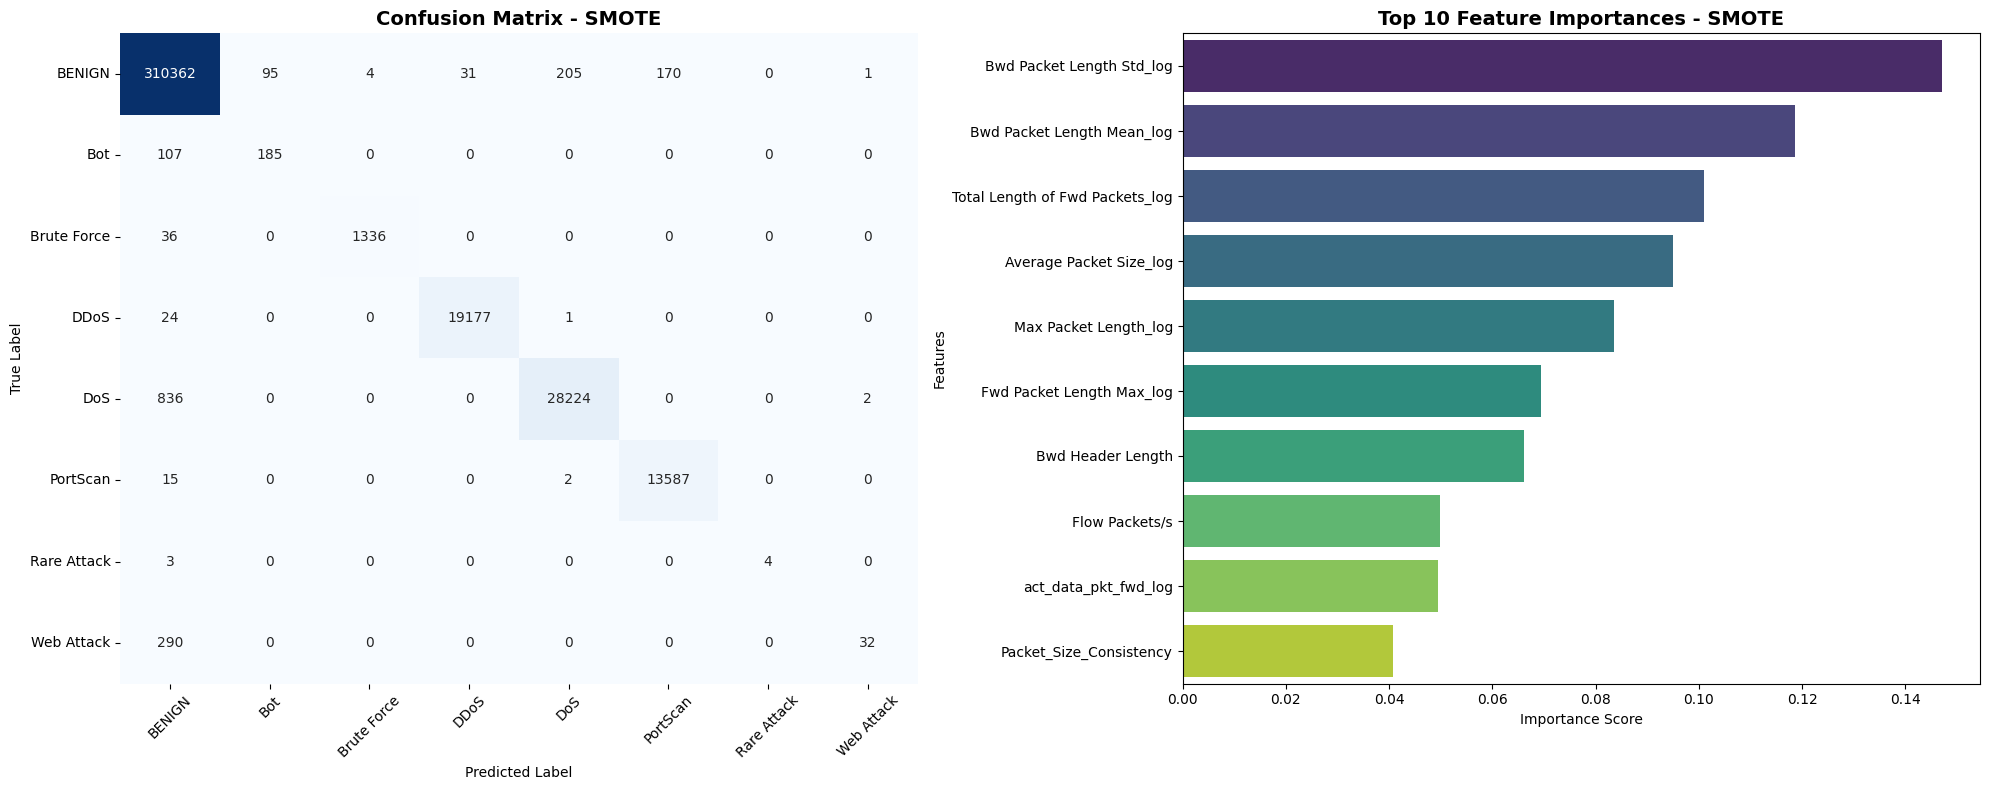

In [38]:
target_names = label_encoder.classes_.tolist()
feature_cols = X_test_z.columns.tolist()

print("[INFO] Generating predictions and evaluating SMOTE Random Forest...")

y_pred_smote = rf_smote.predict(X_test_z)

print("\n" + "=" * 60)
print("Random Forest with SMOTE - Test Set")
print("=" * 60)

print(f"Accuracy Score : {accuracy_score(y_test_encoded, y_pred_smote):.4f}")
print(f"Macro F1-Score : {f1_score(y_test_encoded, y_pred_smote, average='macro'):.4f}")

print("-" * 60)
print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_smote,
        target_names=target_names,
        zero_division=0
    )
)

print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

cm = confusion_matrix(
    y_test_encoded,
    y_pred_smote
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=target_names,
    yticklabels=target_names
)

axes[0].set_title(
    "Confusion Matrix - SMOTE",
    fontsize=14,
    fontweight="bold"
)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].tick_params(axis="x", rotation=45)

importances = rf_smote.feature_importances_

top_n = min(10, len(feature_cols))
indices = np.argsort(importances)[::-1][:top_n]

feature_labels = [feature_cols[i] for i in indices]

sns.barplot(
    x=importances[indices],
    y=feature_labels,
    ax=axes[1],
    hue=feature_labels,
    palette="viridis",
    legend=False
)

axes[1].set_title(
    "Top 10 Feature Importances - SMOTE",
    fontsize=14,
    fontweight="bold"
)
axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

## XGBoost Baseline

In [65]:
# XGBoost Model

from xgboost import XGBClassifier
import time

start = time.time()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_model.fit(
    X_train_z,
    y_train_encoded
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")
print("XGBoost model trained successfully!")

Training Time: 352.74 seconds
XGBoost model trained successfully!


[INFO] Generating predictions and evaluating XGBoost...

XGBoost - Test Set
Accuracy Score : 0.9945
Macro F1-Score : 0.7643
------------------------------------------------------------

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      1.00    310868
         Bot       1.00      0.41      0.59       292
 Brute Force       1.00      0.97      0.99      1372
        DDoS       1.00      1.00      1.00     19202
         DoS       1.00      0.96      0.98     29062
    PortScan       0.99      1.00      0.99     13604
 Rare Attack       1.00      0.29      0.44         7
  Web Attack       1.00      0.07      0.13       322

    accuracy                           0.99    374729
   macro avg       1.00      0.71      0.76    374729
weighted avg       0.99      0.99      0.99    374729



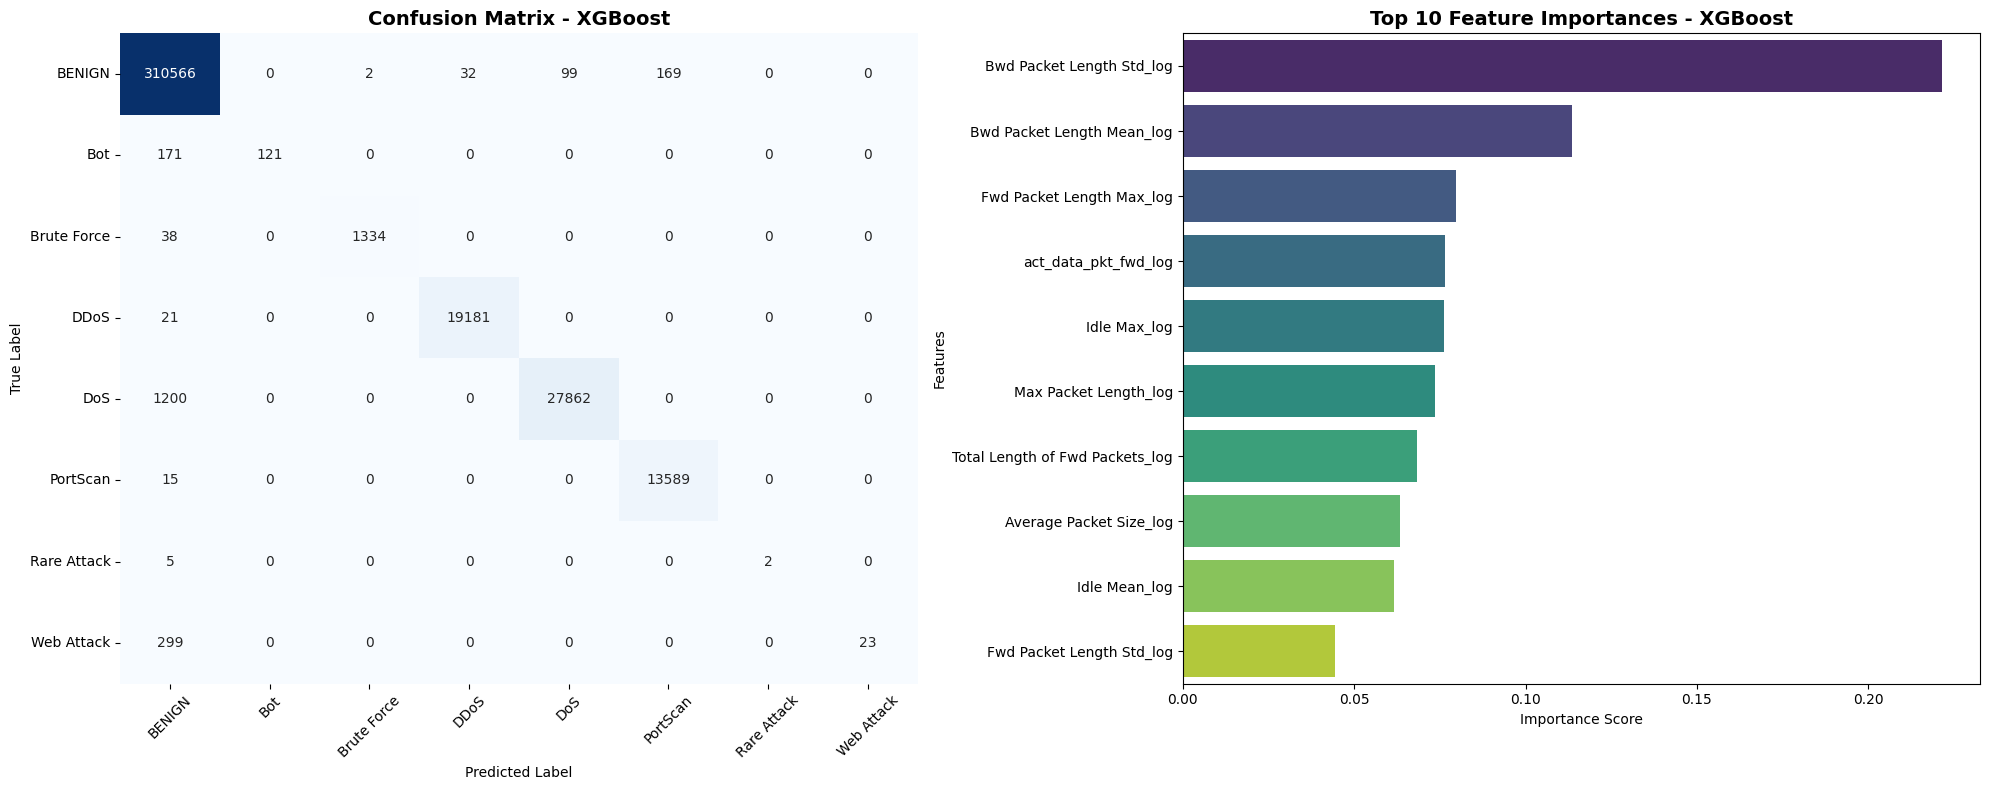

In [ ]:
# XGBoost - Test Evaluation

target_names = label_encoder.classes_.tolist()
feature_cols = X_test_z.columns.tolist()


print("[INFO] Generating predictions and evaluating XGBoost...")


y_pred_xgb = xgb_model.predict(X_test_z)


print("XGBoost - Test Set")

print(
    f"Accuracy Score : "
    f"{accuracy_score(y_test_encoded, y_pred_xgb):.4f}"
)

print(
    f"Macro F1-Score : "
    f"{f1_score(y_test_encoded, y_pred_xgb, average='macro'):.4f}"
)

print("\nClassification Report:")


print(
    classification_report(
        y_test_encoded,
        y_pred_xgb,
        target_names=target_names,
        zero_division=0
    )
)

# Visualization Dashboard

fig, axes = plt.subplots(1, 2, figsize=(20, 8))


# Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred_xgb
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=target_names,
    yticklabels=target_names
)


axes[0].set_title(
    "Confusion Matrix - XGBoost",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].tick_params(axis="x", rotation=45)


# Feature Importance

importances = xgb_model.feature_importances_


top_n = min(10, len(feature_cols))

indices = np.argsort(importances)[::-1][:top_n]


feature_labels = [
    feature_cols[i]
    for i in indices
]


sns.barplot(
    x=importances[indices],
    y=feature_labels,
    ax=axes[1],
    hue=feature_labels,
    palette="viridis",
    legend=False
)


axes[1].set_title(
    "Top 10 Feature Importances - XGBoost",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Features")


plt.tight_layout()
plt.show()

## XGBoost Custom Class Weights

In [78]:
# Custom Class Weights

class_weight = {
    0: 1,
    1: 25,
    2: 10,
    3: 1,
    4: 2,
    5: 1,
    6: 80,
    7: 20
}


# Create sample weights

sample_weights = np.array([
    class_weight[label]
    for label in y_train_encoded
])


# XGBoost Model

start = time.time()

xgb_custom = XGBClassifier(
    n_estimators=300,
    max_depth=30,
    learning_rate=0.1,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)


xgb_custom.fit(
    X_train_z,
    y_train_encoded,
    sample_weight=sample_weights
)


end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

Training Time: 475.51 seconds


[INFO] Generating predictions and evaluating Customized XGBoost...
XGBoost with Custom Class Weights - Test Set
Accuracy Score : 0.9905
Macro F1-Score : 0.7975

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.99      0.99    310868
         Bot       0.60      0.65      0.62       292
 Brute Force       1.00      0.98      0.99      1372
        DDoS       1.00      1.00      1.00     19202
         DoS       0.97      0.98      0.98     29062
    PortScan       0.99      1.00      0.99     13604
 Rare Attack       0.75      0.43      0.55         7
  Web Attack       0.16      0.91      0.27       322

    accuracy                           0.99    374729
   macro avg       0.81      0.87      0.80    374729
weighted avg       0.99      0.99      0.99    374729



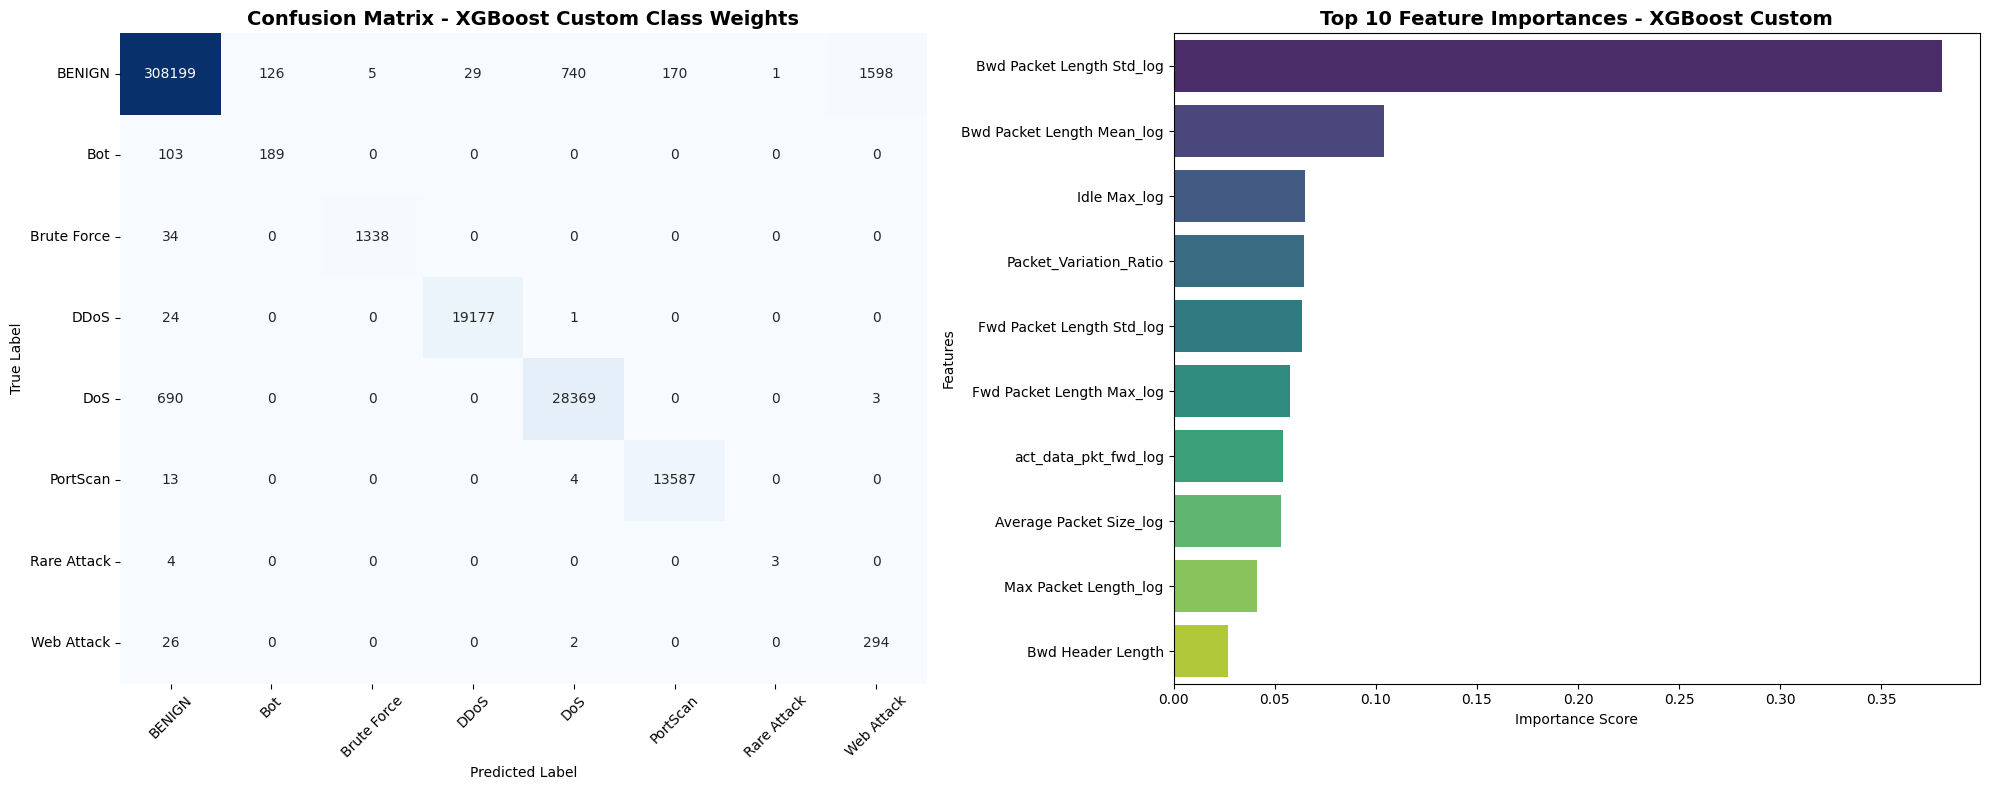

In [79]:
# XGBoost Custom Class Weight - Test Evaluation

target_names = label_encoder.classes_.tolist()
feature_cols = X_test_z.columns.tolist()

print("[INFO] Generating predictions and evaluating Customized XGBoost...")

y_pred_xgb_custom = xgb_custom.predict(X_test_z)

print("XGBoost with Custom Class Weights - Test Set")

print(
    f"Accuracy Score : "
    f"{accuracy_score(y_test_encoded, y_pred_xgb_custom):.4f}"
)

print(
    f"Macro F1-Score : "
    f"{f1_score(y_test_encoded, y_pred_xgb_custom, average='macro'):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_xgb_custom,
        target_names=target_names,
        zero_division=0
    )
)

# Visualization Dashboard

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred_xgb_custom
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=target_names,
    yticklabels=target_names
)

axes[0].set_title(
    "Confusion Matrix - XGBoost Custom Class Weights",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].tick_params(axis="x", rotation=45)

# Feature Importance

importances = xgb_custom.feature_importances_

top_n = min(10, len(feature_cols))

indices = np.argsort(importances)[::-1][:top_n]

feature_labels = [
    feature_cols[i]
    for i in indices
]

sns.barplot(
    x=importances[indices],
    y=feature_labels,
    ax=axes[1],
    hue=feature_labels,
    palette="viridis",
    legend=False
)

axes[1].set_title(
    "Top 10 Feature Importances - XGBoost Custom",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

## XGBoost Balanced Class Weight

In [83]:
# Calculate balanced sample weights

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

# XGBoost - Balanced Class Weight
xgb_balanced = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

start = time.time()

xgb_balanced.fit(
    X_train_z,
    y_train_encoded,
    sample_weight=sample_weights
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")
print("XGBoost Balanced trained successfully!")

Training Time: 327.80 seconds
XGBoost Balanced trained successfully!


[INFO] Generating predictions and evaluating XGBoost Balanced...
XGBoost Balanced - Test Set
Accuracy Score : 0.9461
Macro F1-Score : 0.6843

Classification Report:
              precision    recall  f1-score   support

      BENIGN       1.00      0.94      0.97    310868
         Bot       0.03      0.98      0.06       292
 Brute Force       0.54      0.98      0.70      1372
        DDoS       1.00      1.00      1.00     19202
         DoS       0.92      0.99      0.95     29062
    PortScan       0.99      1.00      0.99     13604
 Rare Attack       1.00      0.57      0.73         7
  Web Attack       0.04      0.96      0.08       322

    accuracy                           0.95    374729
   macro avg       0.69      0.93      0.68    374729
weighted avg       0.99      0.95      0.97    374729



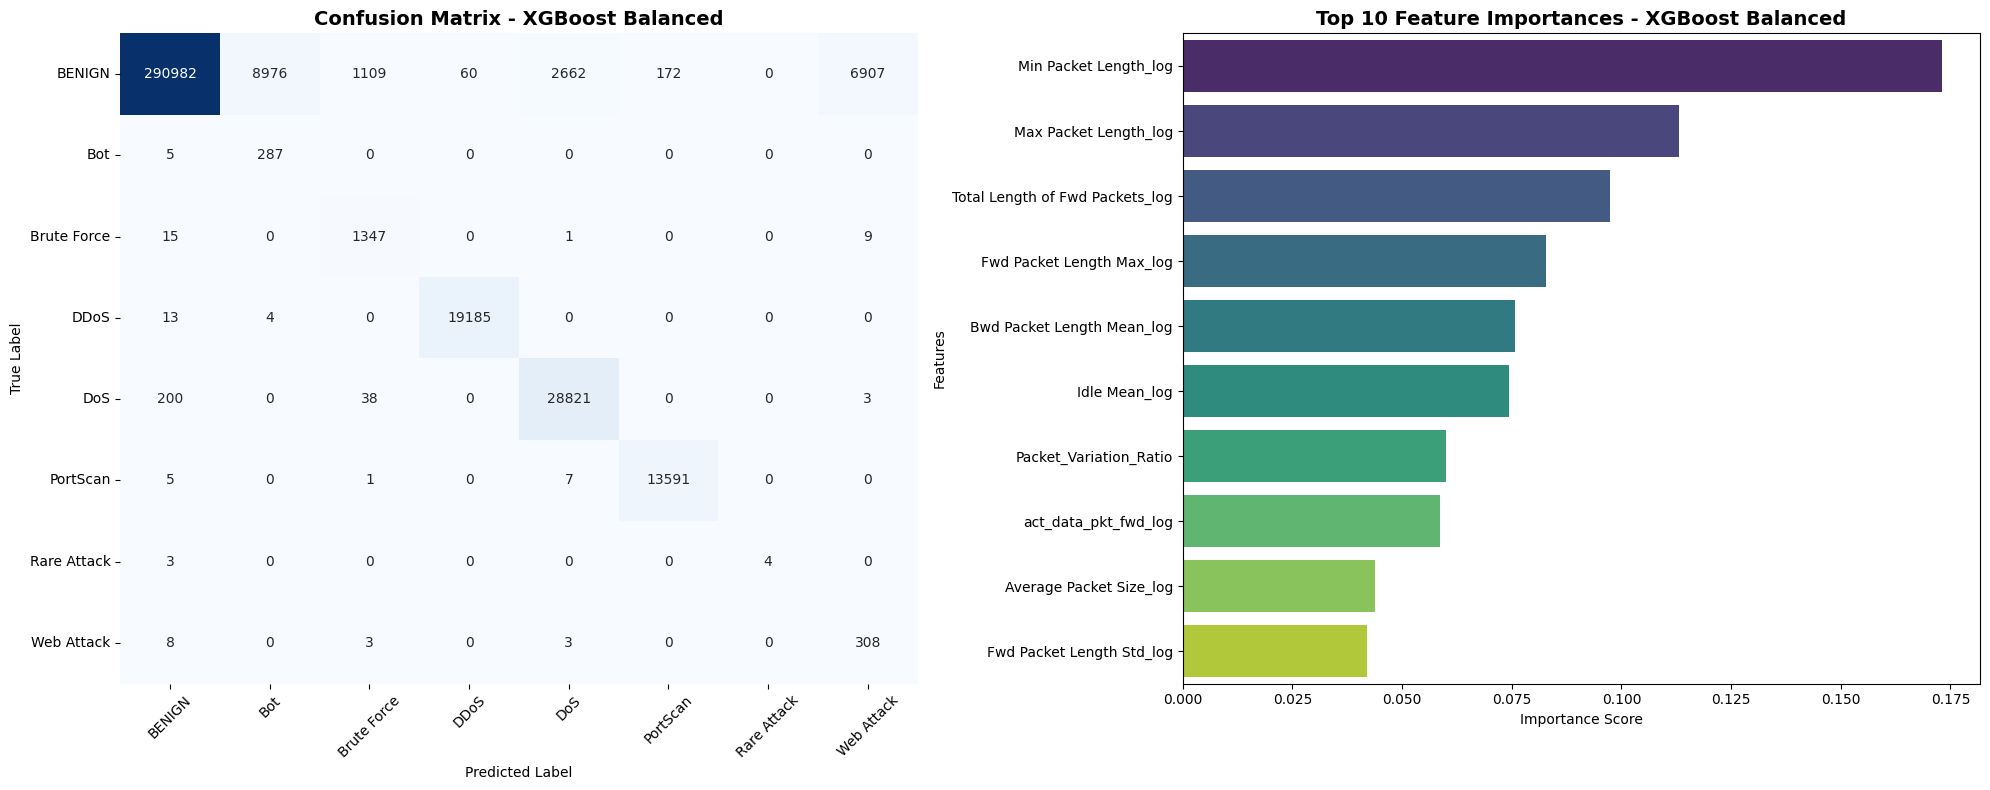

In [84]:
# XGBoost Balanced - Test Evaluation

target_names = label_encoder.classes_.tolist()
feature_cols = X_test_z.columns.tolist()

print("[INFO] Generating predictions and evaluating XGBoost Balanced...")

y_pred_xgb_balanced = xgb_balanced.predict(X_test_z)

print("XGBoost Balanced - Test Set")

print(
    f"Accuracy Score : "
    f"{accuracy_score(y_test_encoded, y_pred_xgb_balanced):.4f}"
)

print(
    f"Macro F1-Score : "
    f"{f1_score(y_test_encoded, y_pred_xgb_balanced, average='macro'):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_xgb_balanced,
        target_names=target_names,
        zero_division=0
    )
)


# Visualization Dashboard

fig, axes = plt.subplots(1, 2, figsize=(20, 8))


# Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred_xgb_balanced
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=target_names,
    yticklabels=target_names
)

axes[0].set_title(
    "Confusion Matrix - XGBoost Balanced",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].tick_params(axis="x", rotation=45)


# Feature Importance

importances = xgb_balanced.feature_importances_

top_n = min(10, len(feature_cols))

indices = np.argsort(importances)[::-1][:top_n]

feature_labels = [
    feature_cols[i]
    for i in indices
]

sns.barplot(
    x=importances[indices],
    y=feature_labels,
    ax=axes[1],
    hue=feature_labels,
    palette="viridis",
    legend=False
)

axes[1].set_title(
    "Top 10 Feature Importances - XGBoost Balanced",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

## XGBoost + SMOTE

In [85]:
# XGBoost + SMOTE

xgb_smote = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

start = time.time()

xgb_smote.fit(
    X_train_smote,
    y_train_smote
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")
print("XGBoost + SMOTE trained successfully!")

Training Time: 310.51 seconds
XGBoost + SMOTE trained successfully!


[INFO] Generating predictions and evaluating XGBoost + SMOTE...
XGBoost + SMOTE - Test Set
Accuracy Score : 0.9943
Macro F1-Score : 0.7901

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      1.00    310868
         Bot       0.59      0.65      0.62       292
 Brute Force       1.00      0.97      0.98      1372
        DDoS       1.00      1.00      1.00     19202
         DoS       1.00      0.96      0.98     29062
    PortScan       0.99      1.00      0.99     13604
 Rare Attack       1.00      0.43      0.60         7
  Web Attack       0.90      0.08      0.15       322

    accuracy                           0.99    374729
   macro avg       0.93      0.76      0.79    374729
weighted avg       0.99      0.99      0.99    374729



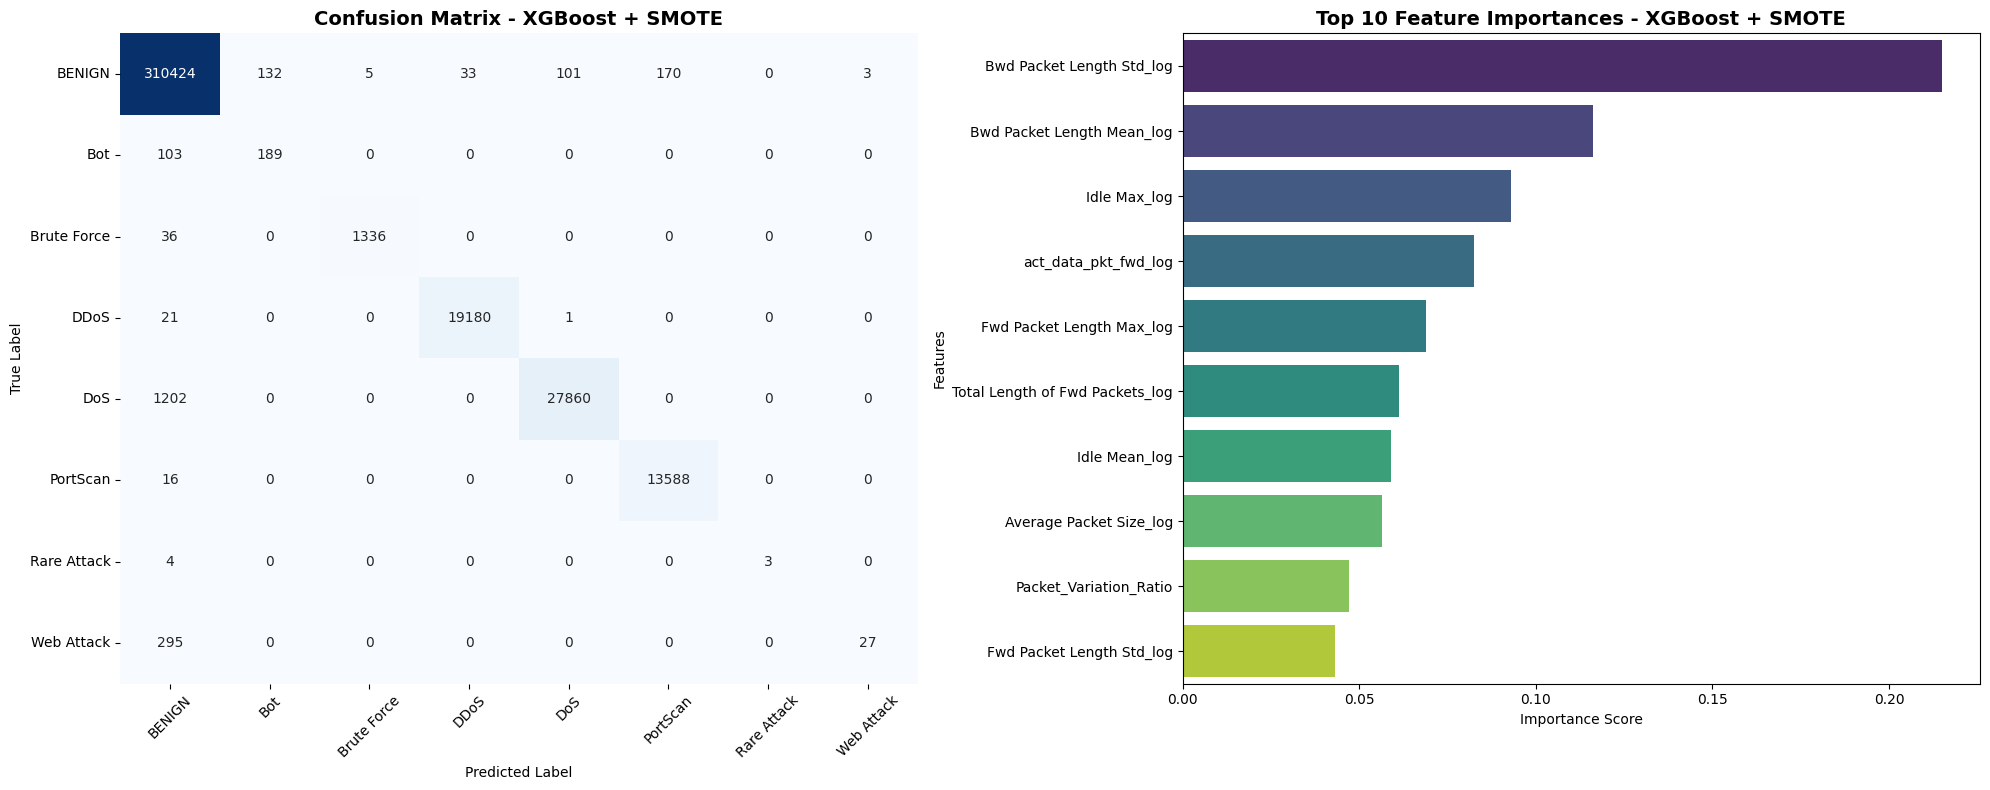

In [86]:
# XGBoost + SMOTE - Test Evaluation

target_names = label_encoder.classes_.tolist()
feature_cols = X_test_z.columns.tolist()

print("[INFO] Generating predictions and evaluating XGBoost + SMOTE...")

y_pred_xgb_smote = xgb_smote.predict(X_test_z)

print("XGBoost + SMOTE - Test Set")

print(
    f"Accuracy Score : "
    f"{accuracy_score(y_test_encoded, y_pred_xgb_smote):.4f}"
)

print(
    f"Macro F1-Score : "
    f"{f1_score(y_test_encoded, y_pred_xgb_smote, average='macro'):.4f}"
)

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_xgb_smote,
        target_names=target_names,
        zero_division=0
    )
)

# Visualization Dashboard

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Confusion Matrix

cm = confusion_matrix(
    y_test_encoded,
    y_pred_xgb_smote
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=axes[0],
    cbar=False,
    annot_kws={"size": 10},
    xticklabels=target_names,
    yticklabels=target_names
)

axes[0].set_title(
    "Confusion Matrix - XGBoost + SMOTE",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")
axes[0].tick_params(axis="x", rotation=45)

# Feature Importance

importances = xgb_smote.feature_importances_

top_n = min(10, len(feature_cols))

indices = np.argsort(importances)[::-1][:top_n]

feature_labels = [
    feature_cols[i]
    for i in indices
]

sns.barplot(
    x=importances[indices],
    y=feature_labels,
    ax=axes[1],
    hue=feature_labels,
    palette="viridis",
    legend=False
)

axes[1].set_title(
    "Top 10 Feature Importances - XGBoost + SMOTE",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("Importance Score")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

# Multi Classification Using MLP

In [82]:
input_shape = X_train_z.shape[1]
num_classes = len(label_encoder.classes_)

model = Sequential([
    Input(shape=(input_shape,)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.30),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.25),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.20),

    Dense(16, activation="relu"),

    Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,200 (55.47 KB)

 Trainable params: 13,752 (53.72 KB)

 Non-trainable params: 448 (1.75 KB)

In [89]:
# ==========================================================
# Early Stopping
# ==========================================================
early_stopping = EarlyStopping(
    monitor="val_loss",          # Better than val_accuracy for multiclass
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# ==========================================================
# Learning Rate Scheduler
# ==========================================================
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,                  # Reduce LR by 50%
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# ==========================================================
# Compute Class Weights
# ==========================================================
classes = np.unique(y_train_encoded)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_encoded
)

weights = np.clip(weights, 1.0, 100.0)
class_weight_dict = dict(zip(classes, weights))

print("Class Weights:")
print(class_weight_dict)

Class Weights:
{np.int64(0): np.float64(1.0), np.int64(1): np.float64(100.0), np.int64(2): np.float64(34.12571033075914), np.int64(3): np.float64(2.4393787105509843), np.int64(4): np.float64(1.6117704340405619), np.int64(5): np.float64(3.4431241822378382), np.int64(6): np.float64(100.0), np.int64(7): np.float64(100.0)}


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [91]:
start = time.time()

history = model.fit(
    X_train_z,
    y_train_encoded,

    validation_data=(
        X_val_z,
        y_val_encoded
    ),

    epochs=100,
    batch_size=1024,

    class_weight=class_weight_dict,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")

Epoch 1/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.8939 - loss: 0.6047 - val_accuracy: 0.9207 - val_loss: 0.1702 - learning_rate: 0.0010
Epoch 2/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9245 - loss: 0.3517 - val_accuracy: 0.9402 - val_loss: 0.1270 - learning_rate: 0.0010
Epoch 3/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9268 - loss: 0.3166 - val_accuracy: 0.9272 - val_loss: 0.1401 - learning_rate: 0.0010
Epoch 4/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9282 - loss: 0.2952 - val_accuracy: 0.9390 - val_loss: 0.1260 - learning_rate: 0.0010
Epoch 5/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.9298 - loss: 0.2821 - val_accuracy: 0.9467 - val_loss: 0.1162 - learning_rate: 0.0010
Epoch 6/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9307 - loss: 0.2776 - val_accuracy: 0.9117 - val_loss: 0.1557 - learning_rate: 0.0010
Epoch 7/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accu

In [92]:
# Evaluate Model

test_loss, test_accuracy = model.evaluate(
    X_test_z,
    y_test_encoded,
    verbose=0
)

# Predict probabilities
y_pred_prob = model.predict(X_test_z, verbose=0)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Calculate metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test_encoded,
    y_pred,
    average="weighted"
)

print("=" * 50)
print("Test Evaluation")
print("=" * 50)

print(f"Loss      : {test_loss:.4f}")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test_encoded, y_pred))

Test Evaluation
Loss      : 0.1021
Accuracy  : 0.9512
Precision : 0.9910
Recall    : 0.9512
F1-score  : 0.9701

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.95      0.97    310868
           1       0.21      0.65      0.31       292
           2       0.91      0.97      0.94      1372
           3       1.00      1.00      1.00     19202
           4       0.94      0.94      0.94     29062
           5       0.99      0.99      0.99     13604
           6       0.12      0.29      0.17         7
           7       0.02      0.92      0.04       322

    accuracy                           0.95    374729
   macro avg       0.65      0.84      0.67    374729
weighted avg       0.99      0.95      0.97    374729



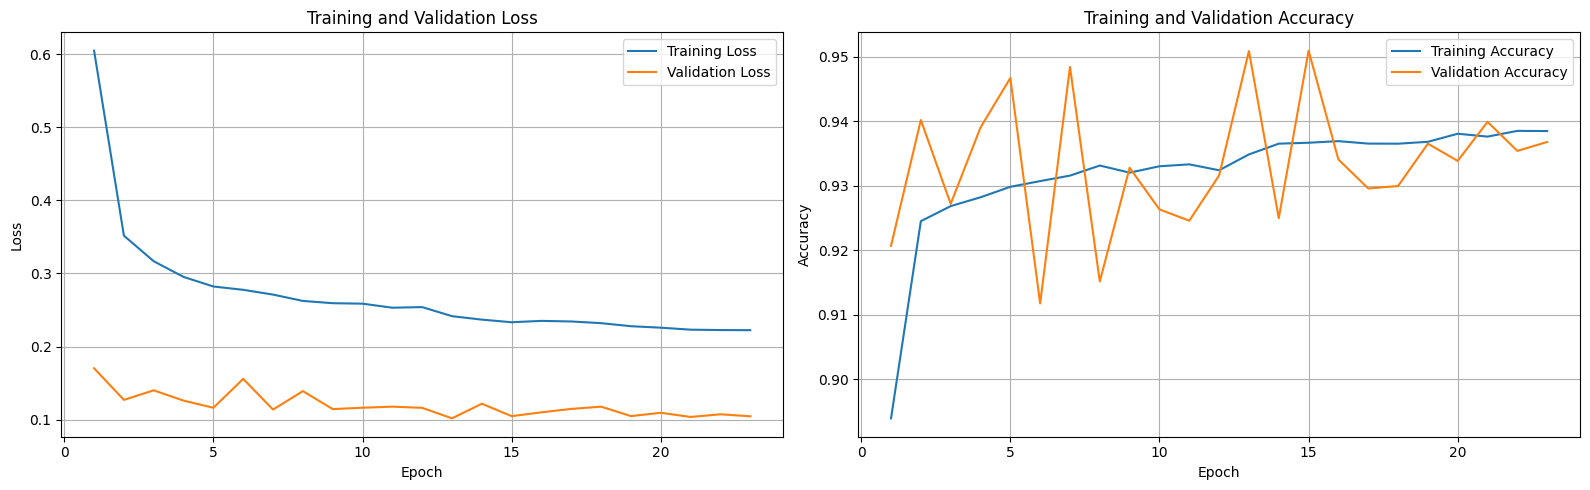

In [93]:
# Extract metrics

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

train_acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

epochs = range(1, len(train_loss) + 1)


# Create two plots side by side

fig, axes = plt.subplots(1, 2, figsize=(16, 5))


# Training & Validation Loss

axes[0].plot(
    epochs,
    train_loss,
    label="Training Loss"
)

axes[0].plot(
    epochs,
    val_loss,
    label="Validation Loss"
)

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)


# Training & Validation Accuracy

axes[1].plot(
    epochs,
    train_acc,
    label="Training Accuracy"
)

axes[1].plot(
    epochs,
    val_acc,
    label="Validation Accuracy"
)

axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)


plt.tight_layout()
plt.show()

## MLP v2 + Balanced Weights

In [95]:
input_shape = X_train_z.shape[1]
num_classes = len(np.unique(y_train_encoded))

model_v2 = Sequential([
    Input(shape=(input_shape,)),

    Dense(256),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.30),

    Dense(128),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.25),

    Dense(64),
    LeakyReLU(alpha=0.1),
    BatchNormalization(),
    Dropout(0.20),

    Dense(32),
    LeakyReLU(alpha=0.1),

    Dense(num_classes, activation="softmax")
])

model_v2.summary()

c:\Users\COMPUMARTS\anaconda3\envs\ai_env\lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,896 (194.91 KB)

 Trainable params: 49,000 (191.41 KB)

 Non-trainable params: 896 (3.50 KB)

In [96]:
# Compile MLP v2

model_v2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start = time.time()

history_v2 = model_v2.fit(
    X_train_z,
    y_train_encoded,

    validation_data=(
        X_val_z,
        y_val_encoded
    ),

    epochs=100,
    batch_size=1024,

    class_weight=class_weight_dict,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

end = time.time()

print(f"Training Time: {end - start:.2f} seconds")
print("MLP v2 training completed successfully!")

Epoch 1/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - accuracy: 0.9136 - loss: 0.4751 - val_accuracy: 0.9200 - val_loss: 0.1462 - learning_rate: 0.0010
Epoch 2/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9292 - loss: 0.3146 - val_accuracy: 0.9532 - val_loss: 0.1269 - learning_rate: 0.0010
Epoch 3/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9325 - loss: 0.2833 - val_accuracy: 0.9357 - val_loss: 0.1195 - learning_rate: 0.0010
Epoch 4/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9340 - loss: 0.2695 - val_accuracy: 0.9299 - val_loss: 0.1266 - learning_rate: 0.0010
Epoch 5/100
1826/1830 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9336 - loss: 0.2628
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.9356 - loss: 0.2592 - val_accuracy: 0.9391 - val_loss: 0.1262 - learning_rate: 0.0010
Epoch 6/100
1830/1830 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - ac

In [97]:
# MLP v2 - Test Evaluation

print("[INFO] Generating predictions and evaluating MLP v2...")

# Evaluate model
test_loss, test_accuracy = model_v2.evaluate(
    X_test_z,
    y_test_encoded,
    verbose=0
)

# Predict probabilities
y_pred_prob_v2 = model_v2.predict(
    X_test_z,
    verbose=0
)

# Convert probabilities to class labels
y_pred_v2 = np.argmax(
    y_pred_prob_v2,
    axis=1
)

# Metrics
accuracy_v2 = accuracy_score(
    y_test_encoded,
    y_pred_v2
)

precision_v2 = precision_score(
    y_test_encoded,
    y_pred_v2,
    average="weighted",
    zero_division=0
)

recall_v2 = recall_score(
    y_test_encoded,
    y_pred_v2,
    average="weighted",
    zero_division=0
)

f1_v2 = f1_score(
    y_test_encoded,
    y_pred_v2,
    average="weighted",
    zero_division=0
)

macro_f1_v2 = f1_score(
    y_test_encoded,
    y_pred_v2,
    average="macro",
    zero_division=0
)

print("MLP v2 - Test Set")

print(f"Loss              : {test_loss:.4f}")
print(f"Accuracy          : {accuracy_v2:.4f}")
print(f"Weighted Precision: {precision_v2:.4f}")
print(f"Weighted Recall   : {recall_v2:.4f}")
print(f"Weighted F1       : {f1_v2:.4f}")
print(f"Macro F1          : {macro_f1_v2:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test_encoded,
        y_pred_v2,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

[INFO] Generating predictions and evaluating MLP v2...
MLP v2 - Test Set
Loss              : 0.1463
Accuracy          : 0.9200
Weighted Precision: 0.9828
Weighted Recall   : 0.9200
Weighted F1       : 0.9488
Macro F1          : 0.5670

Classification Report:
              precision    recall  f1-score   support

      BENIGN       0.99      0.91      0.95    310868
         Bot       0.02      0.72      0.04       292
 Brute Force       0.47      0.97      0.63      1372
        DDoS       0.99      1.00      0.99     19202
         DoS       0.95      0.92      0.93     29062
    PortScan       0.87      0.99      0.92     13604
 Rare Attack       0.01      0.43      0.02         7
  Web Attack       0.02      0.88      0.04       322

    accuracy                           0.92    374729
   macro avg       0.54      0.85      0.57    374729
weighted avg       0.98      0.92      0.95    374729



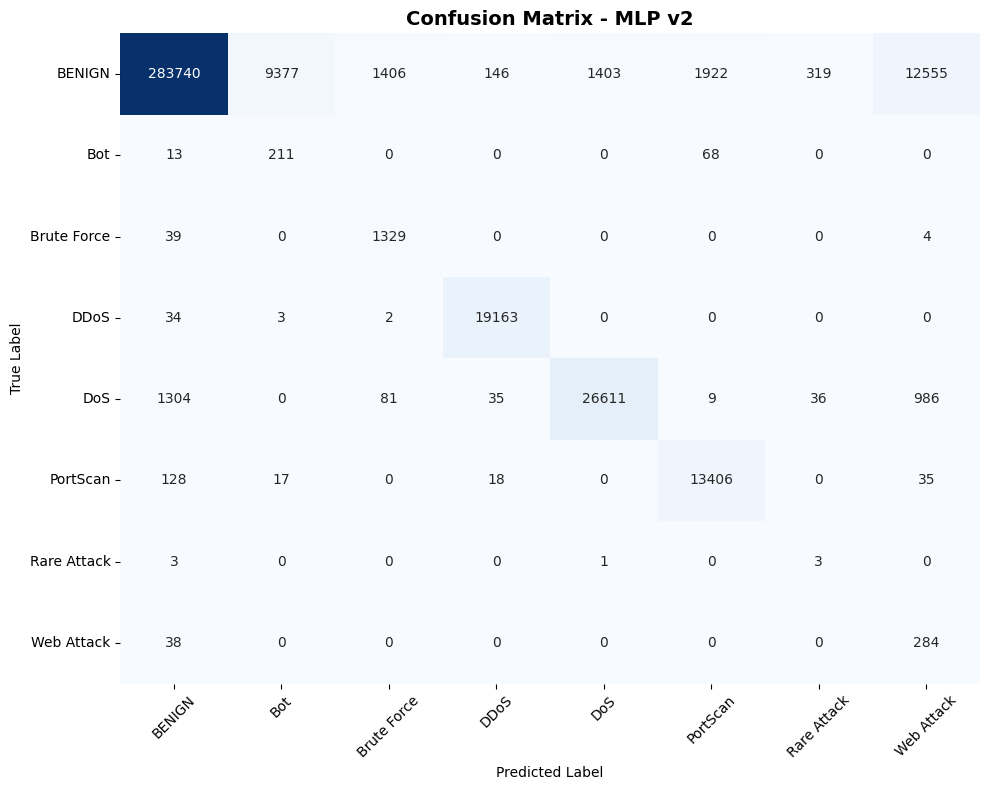

In [98]:
# MLP v2 - Confusion Matrix

cm_v2 = confusion_matrix(
    y_test_encoded,
    y_pred_v2
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_v2,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    "Confusion Matrix - MLP v2",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## Model Comparison

Several models were evaluated using different class-imbalance techniques:

| Model                    |   Accuracy |   Macro F1 |
| ------------------------ | ---------: | ---------: |
| **RF Custom Weights V1** | **99.16%** | **82.46%** |
| RF Custom Weights V2     |     99.16% |     82.45% |
| RF + SMOTE               |      ~100% |     81.00% |
| XGBoost Custom Weights   |     99.05% |     79.75% |
| XGBoost + SMOTE          |     99.43% |     79.01% |
| XGBoost                  |     99.00% |     76.00% |
| XGBoost Balanced         |     94.61% |     68.43% |
| MLP v1                   |     95.12% |     67.00% |
| MLP v2                   |     92.00% |     56.70% |

### Final Model

**Random Forest with Custom Class Weights V1** was selected as the final model because it achieved the highest **Macro F1-score (82.46%)** and **Accuracy (99.16%)**.

A second version (**RF V2**) was also tested with modified class weights, but it achieved almost identical performance (**Macro F1 = 82.45%**), so V1 was retained as the final model.

Macro F1 was prioritized over Accuracy because the dataset is highly imbalanced and performance across minority attack classes is important.
